In [72]:
import pandas as pd
import numpy as np

# Cleaning the data
df = pd.read_csv("house_pricing_dataset.csv")
df = df.dropna(axis=1)
df = df.replace({'yes': 1, 'no': 0})
df = df.replace({'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0})

# Scaling Features
features = [
    'area',
    'bedrooms',
    'bathrooms',
    'furnishingstatus',
    'parking',
    'basement',
    'mainroad',
    'guestroom',
    'airconditioning',
    'prefarea',
    'stories'
]

for col in features:
    df[col] = (df[col] - df[col].mean()) / df[col].std()

# Make capsules
X_capsules = np.c_[
    df['area'].to_numpy(dtype=float),
    df['bedrooms'].to_numpy(dtype=float),
    df['bathrooms'].to_numpy(dtype=float),
    df['furnishingstatus'].to_numpy(dtype=float),
    df['parking'].to_numpy(dtype=float),
    df['basement'].to_numpy(dtype=float),
    df['mainroad'].to_numpy(dtype=float),
    df['guestroom'].to_numpy(dtype=float),
    df['airconditioning'].to_numpy(dtype=float),
    df['prefarea'].to_numpy(dtype=float),
    df['stories'].to_numpy(dtype=float),
]
y = df['price'].to_numpy(dtype=float)


In [73]:
def cost(y, y_hat):
    return (1 / (2 * len(y))) * np.sum(np.square(y_hat - y))

In [74]:
w = np.zeros(X_capsules.shape[1])  # 11 weights
b = 0.0

epochs = 100000
alpha = 0.01

for epoch in range(epochs):
    f_wb = np.dot(X_capsules, w) + b
    lost = cost(y, f_wb)
    w = w - alpha * np.dot(X_capsules.T, (f_wb - y)) / len(y)
    b = b - alpha * np.sum(f_wb - y) / len(y)

print(f"Epoch {epoch}: Cost {lost} | w: {w} | b: {b}")

Epoch 99999: Cost 574664552172.4238 | w: [527414.44493651  92319.2182125  508251.00599601 168511.87081157
 256109.39123275 173926.96489665 145753.13218224 114037.34866081
 366887.59131543 263952.10509106 397655.86526643] | b: 4766729.247706376


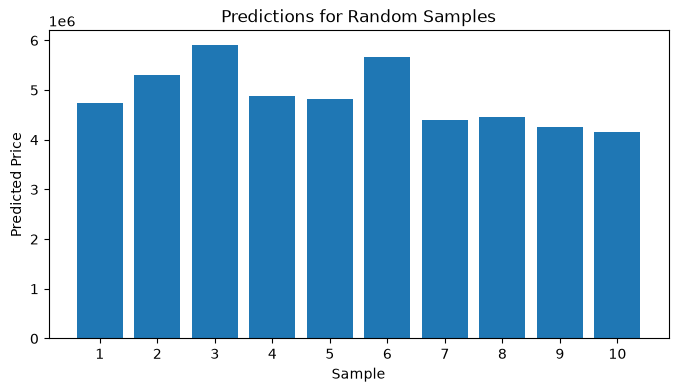

In [75]:
import matplotlib.pyplot as plt

# Example predictions for many random samples
rng = np.random.default_rng(42)

random_samples = rng.normal(loc=0.0, scale=1.0, size=(10, X_capsules.shape[1]))
predictions = np.dot(random_samples, w) + b

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(predictions) + 1), predictions)
plt.xlabel('Sample')
plt.ylabel('Predicted Price')
plt.title('Predictions for Random Samples')
plt.xticks(range(1, len(predictions) + 1))
plt.show()
